In [2]:
import yfinance as yf
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
stocks = ["AMZN", "MSFT", "GOOG"]  # List of stock tickers
#start = dt.datetime.today() - dt.timedelta(360) # 30 days ago
#end = dt.datetime.today()

ohlcv_data = {}  # Dictionary to hold OHLCV data. Key-Value pair: Ticker-DataFrame

# get closing prices for each stock
for ticker in stocks:
    temp = yf.download(ticker, period="1y", interval="1d")
    temp.dropna(how="any", inplace=True) # type: ignore
    ohlcv_data[ticker] = temp


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
# adx - average directional index
# measured strength of a trend
# 0-100, 100 being very strong

def atr(DF, n=14):
    df = DF.copy()

    df["H-L"] = df["High"] - df["Low"]
    df["H-PC"] = df["High"] - df["Close"].shift(1)
    df["L-PC"] = df["Low"] - df["Close"].shift(1)

    # max along the rows between all three gives true range
    df["TR"] = df[["H-L", "H-PC", "L-PC"]].max(axis=1, skipna=False)

    df["ATR"] = df["TR"].ewm(com=n, min_periods=n).mean()
    return df["ATR"]

def adx(DF, n = 20):
    df = DF.copy()

    df["ATR"] = atr(df, n)

    # upMove and downMove
    df["upMove"] = df["High"] - df["High"].shift(1)
    df["downMove"] = df["Low"].shift(1) - df["Low"]

    # +DM and -DM
    df["+dm"] = np.where((df["upMove"] > df["downMove"]) & (df["upMove"] > 0), df["upMove"], 0)
    df["-dm"] = np.where((df["downMove"] > df["upMove"]) & (df["downMove"] > 0), df["downMove"], 0)

    # +di and -di
    df["+di"] = 100 * (df["+dm"]/df["ATR"]).ewm(span=n, min_periods=n).mean()
    df["-di"] = 100 * (df["-dm"]/df["ATR"]).ewm(span=n, min_periods=n).mean()

    # adx
    df["adx"] = 100 * abs((df["+di"] - df["-di"])/(df["+di"] + df["-di"])).ewm(span=n, min_periods=n).mean()

    return df["adx"]

for ticker in ohlcv_data:
    ohlcv_data[ticker]["ADX"] = adx(ohlcv_data[ticker])



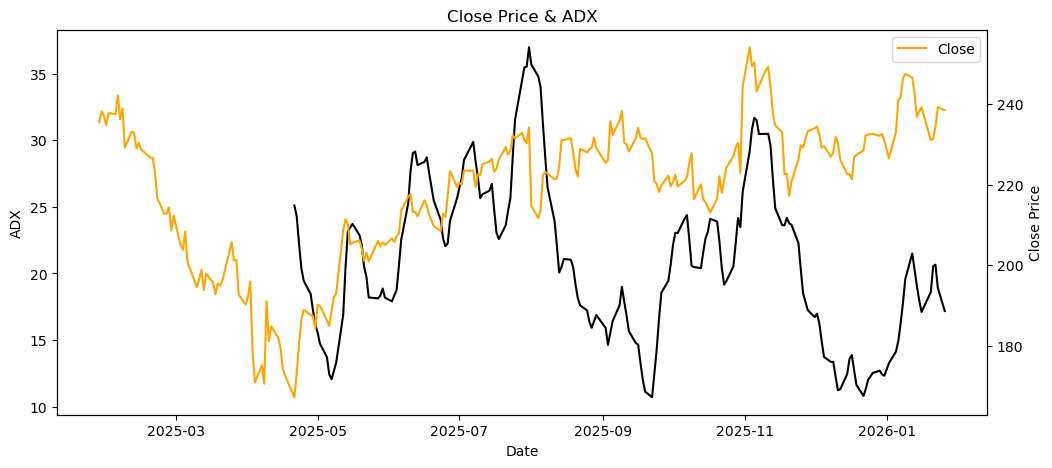

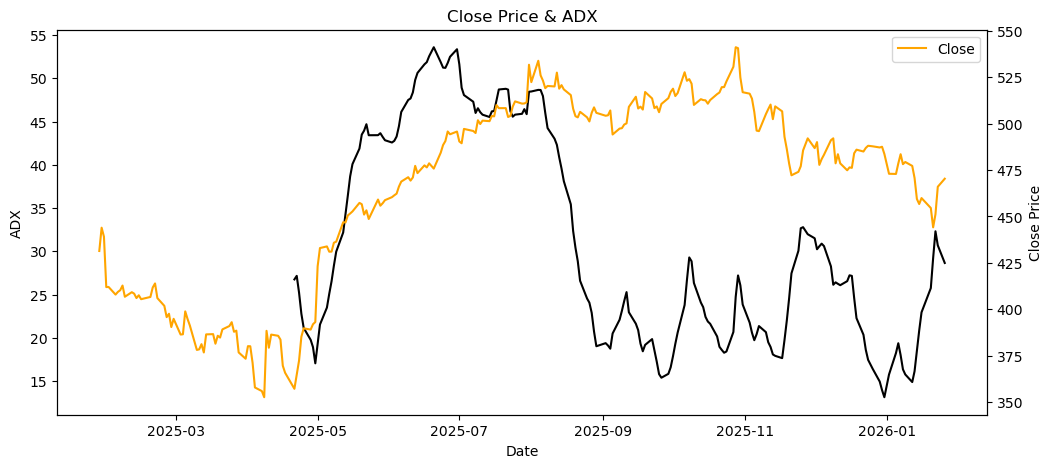

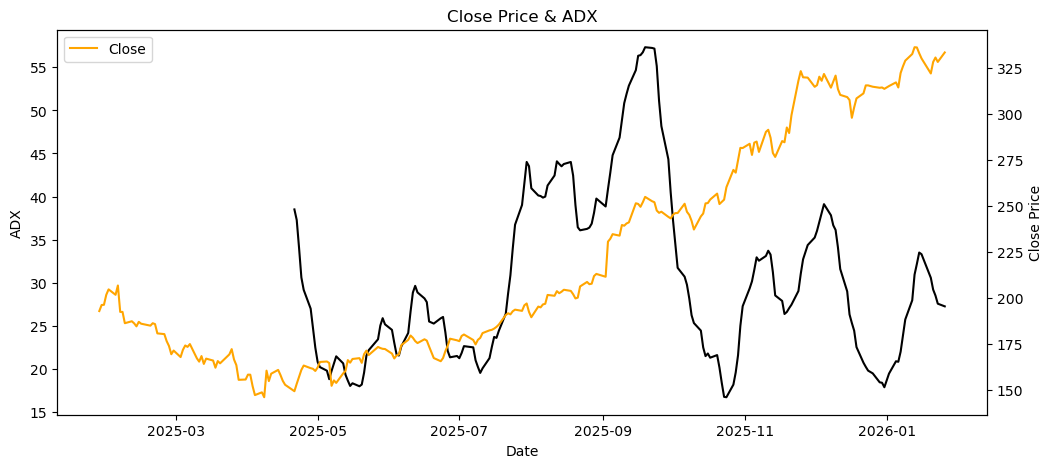

In [8]:
# graphing the adx

for ticker in ohlcv_data:
    df = ohlcv_data[ticker].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(df.index, df["ADX"], label="ADX", color="black")
    ax1.set_ylabel("ADX")
    
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["Close"], label="Close", color="orange")
    ax2.set_ylabel("Close Price")

    ax1.set_xlabel("Date")

    plt.title("Close Price & ADX")
    plt.legend()

    plt.show()